In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, recall_score, precision_score

""Dataset""

In [2]:
dir_path = os.listdir("Training")

In [3]:
dir_path

['no_tumor', 'pituitary_tumor', 'Yes']

""Mapping""

In [4]:
classes = { 'Yes':1,'no_tumor':0}

In [5]:
x = []
y = []
for i in classes:
    path = "Training/" + i
    print(path)
    for j in os.listdir(path):
       # print(j)   # All Images in yesfold
        image = cv2.imread(path + "/" + j, 0)  # 0 means grayscale (single channel)
        # print(image)
        image = cv2.resize(image,(200,200))
        # print(image)
        x.append(image)
        y.append(classes[i])
x = np.array(x)
y = np.array(y)

Training/Yes
Training/no_tumor


In [6]:
np.unique(y)

array([0, 1])

In [7]:
y.size

2870

""Visualize Data""

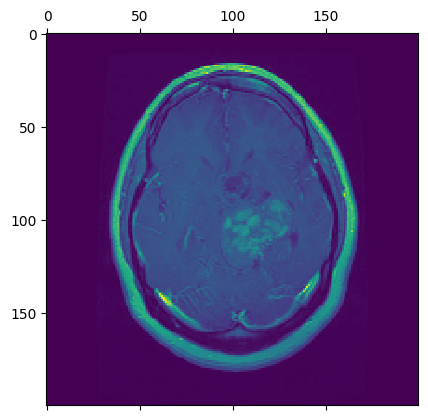

In [8]:
plt.matshow(x[0])

""Prepare Data""

In [9]:
x = x / 255.0

In [10]:
x = x.reshape(len(x), -1)
x.shape

(2870, 40000)

In [11]:
pd.Series(y).value_counts()

1    2475
0     395
Name: count, dtype: int64

""Splitting Data""

In [12]:
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [13]:
x_train.shape

(2296, 40000)

In [14]:
y_train.shape

(2296,)

""Featuer Scalling""

""train Mode""

In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
logiR = LogisticRegression(C =0.1 ,random_state = 42)

In [17]:
logiR.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [18]:
y_pred = logiR.predict(x_test)
accuracy_score(y_test, y_pred)

0.9355400696864111

In [19]:
confusion_matrix(y_test, y_pred)

array([[ 51,  27],
       [ 10, 486]])

In [20]:
randomF = RandomForestClassifier(n_estimators = 100, criterion = "gini",  random_state = 42)

In [21]:
randomF.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
DecTree = DecisionTreeClassifier(criterion = "gini", random_state = 42)

In [23]:
DecTree.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [24]:
SupportVector = SVC()

In [25]:
SupportVector.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
print("Training Score", logiR.score(x_train, y_train))
print("Testing Score", logiR.score(x_test, y_test))

Training Score 1.0
Testing Score 0.9355400696864111


In [27]:
print("Training Score", randomF.score(x_train, y_train))
print("Testing Score", randomF.score(x_test, y_test))

Training Score 1.0
Testing Score 0.9494773519163763


In [28]:
print("Training Score", DecTree.score(x_train, y_train))
print("Testing Score", DecTree.score(x_test, y_test))

Training Score 1.0
Testing Score 0.9181184668989547


In [51]:
print("Training Score", SupportVector.score(x_train, y_train))
print("Testing Score", SupportVector.score(x_test, y_test))

Training Score 0.980836236933798
Testing Score 0.9250871080139372


""Prediction""

In [30]:
pred = SupportVector.predict(x_test)
np.where(y_test!= pred)

(array([  4,  16,  28,  48,  69,  88, 115, 116, 137, 145, 193, 197, 202,
        233, 278, 282, 285, 300, 301, 315, 322, 331, 337, 344, 353, 360,
        369, 379, 407, 411, 412, 479, 494, 507, 509, 518, 520, 532, 548,
        549, 559, 561, 564]),)

""Test Model""

In [31]:
desc = {0 : "No Tumor", 1 : "Positive Tumor"}

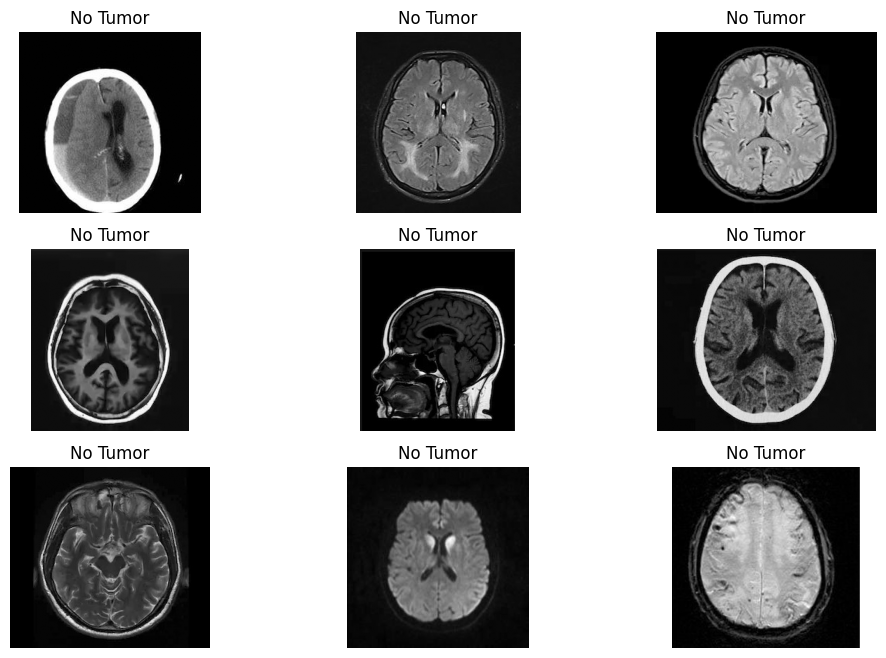

In [32]:
plt.figure(figsize = (12, 8))
path = os.listdir("Testing/no_tumor/")
c = 1
for i in os.listdir("Testing/no_tumor/")[:9]:
    plt.subplot(3,3 ,c)

    img = cv2.imread("Testing/no_tumor/"+i,0)
    img1 = cv2.resize(img, (200, 200))
    img1 = img1.reshape(1,-1)/255
    p = randomF.predict(img1)
    plt.title(desc[p[0]])
    plt.imshow(img, cmap = "gray")
    plt.axis("off")
    c += 1

    

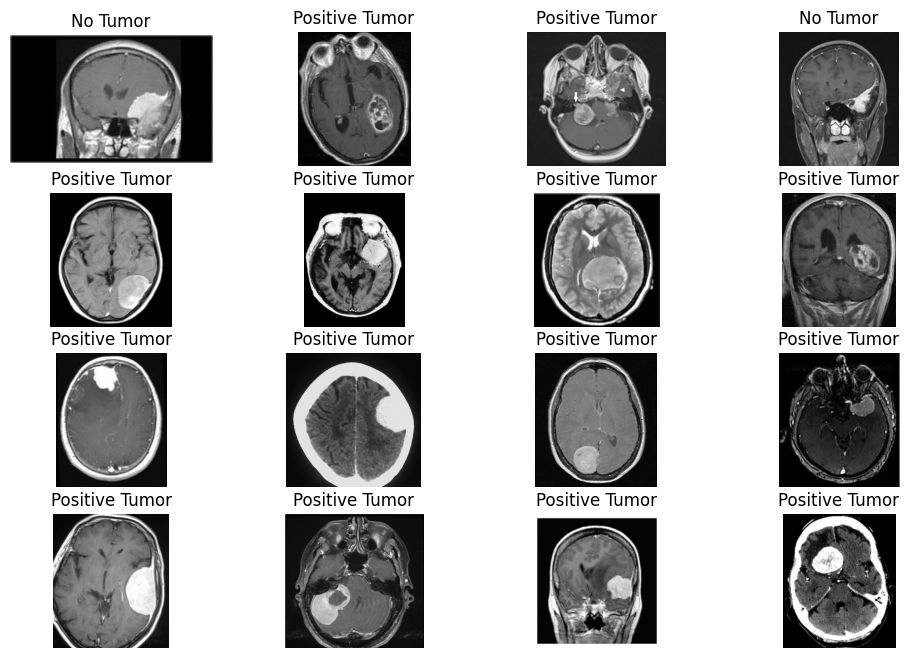

In [33]:
plt.figure(figsize = (12, 8))
path = os.listdir("Testing/meningioma_tumor/")
c = 1
for i in os.listdir("Testing/meningioma_tumor/")[:16]:
    plt.subplot(4,4 ,c)

    img = cv2.imread("Testing/meningioma_tumor/"+i,0)
    img1 = cv2.resize(img, (200, 200))
    img1 = img1.reshape(1,-1)/255
    p = randomF.predict(img1)
    plt.title(desc[p[0]])
    plt.imshow(img, cmap = "gray")
    plt.axis("off")
    c += 1

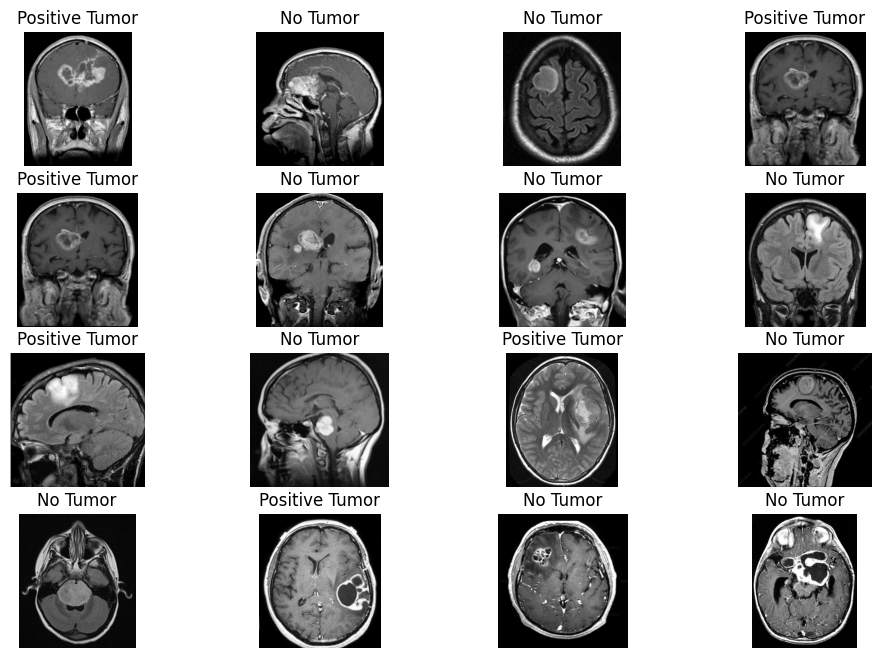

In [34]:
plt.figure(figsize = (12, 8))
path = os.listdir("Testing/glioma_tumor/")
c = 1
for i in os.listdir("Testing/glioma_tumor/")[:16]:
    plt.subplot(4,4 ,c)

    img = cv2.imread("Testing/glioma_tumor/"+i,0)
    img1 = cv2.resize(img, (200, 200))
    img1 = img1.reshape(1,-1)/255
    p = randomF.predict(img1)
    plt.title(desc[p[0]])
    plt.imshow(img, cmap = "gray")
    plt.axis("off")
    c += 1

""Confusion Matrix by Heatmap""

In [35]:
lg_pred = logiR.predict(x_test)

In [36]:
random_pred = randomF.predict(x_test)

In [37]:
DcTree_pred = DecTree.predict(x_test)

In [38]:
SVC_pred = SupportVector.predict(x_test)

In [39]:
conf_matrix_lg = confusion_matrix(y_test,lg_pred)
conf_matrix_random = confusion_matrix(y_test,random_pred)
conf_matrix_DcTree = confusion_matrix(y_test,DcTree_pred)
conf_matrix_SVC = confusion_matrix(y_test,SVC_pred)

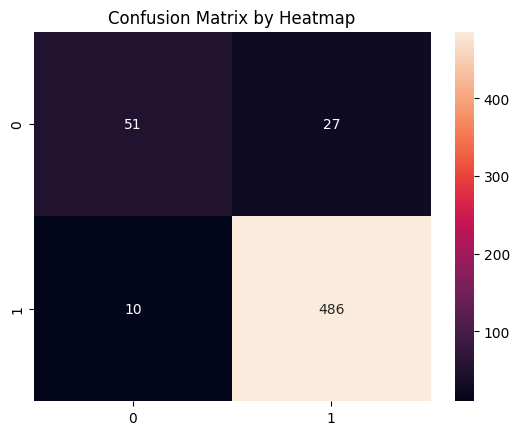

In [40]:
sns.heatmap(conf_matrix_lg, annot = True, fmt = "d", color = "pink")
plt.title("Confusion Matrix by Heatmap")
plt.show()

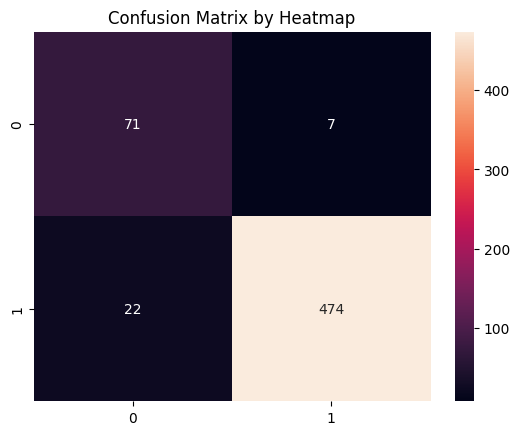

In [41]:
sns.heatmap(conf_matrix_random, annot = True, fmt = "d", color = "blue")
plt.title("Confusion Matrix by Heatmap")
plt.show()

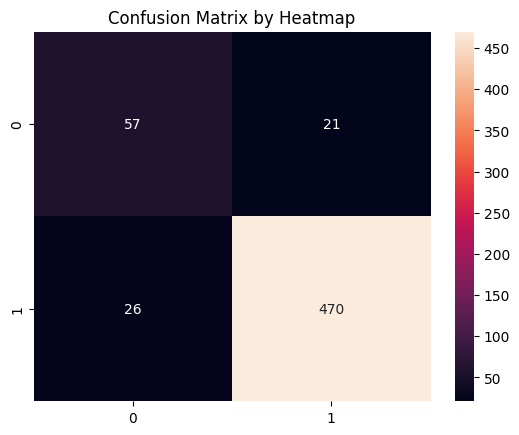

In [42]:
sns.heatmap(conf_matrix_DcTree, annot = True, fmt = "d", color = "blue")
plt.title("Confusion Matrix by Heatmap")
plt.show()

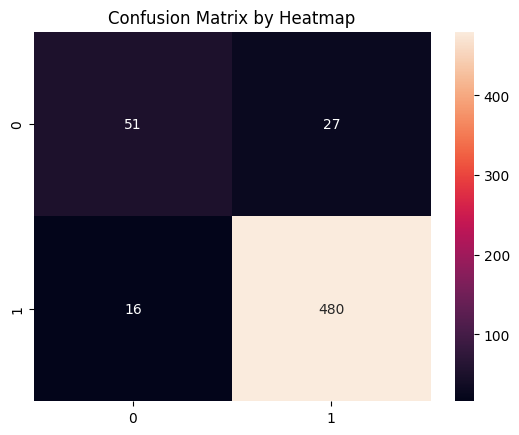

In [43]:
sns.heatmap(conf_matrix_SVC, annot = True, fmt = "d", color = "blue")
plt.title("Confusion Matrix by Heatmap")
plt.show()

""Accurancy Score""

In [44]:
accu_score_RandF = accuracy_score(y_test,random_pred)
print(accu_score_RandF)

0.9494773519163763


In [45]:
classi_report_RandF = classification_report(y_test,random_pred)
print(classi_report_RandF)

              precision    recall  f1-score   support

           0       0.76      0.91      0.83        78
           1       0.99      0.96      0.97       496

    accuracy                           0.95       574
   macro avg       0.87      0.93      0.90       574
weighted avg       0.96      0.95      0.95       574



In [46]:
preci_score = precision_score(y_test,random_pred)
print(preci_score)

0.9854469854469855


In [47]:
recall_score = recall_score(y_test,random_pred)
print(recall_score)

0.9556451612903226


In [48]:
f1_sco = f1_score(y_test,random_pred)*100
print(f1_sco)

97.0317297850563


In [49]:
import joblib

In [50]:
joblib.dump(randomF,"Brain_tumor.joblib")

['Brain_tumor.joblib']